<div style="background: linear-gradient(to bottom, #F566BA, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Captioned Icons — Exploration
Browses `data/icons_captioned.jsonl`: one randomly drawn monochrome static icon per path-count tier (1–5 paths), showing its Iconify ID alongside short and long captions.

</div>

In [20]:
import io
import json
import random
import re
import sys
import textwrap
from pathlib import Path

import cairosvg
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
from PIL import Image

sys.path.insert(0, "..")
from brand import blue

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "text.color":       "black",
    "font.family":      "sans-serif",
    "figure.dpi":       150,
})

_ANIM_RE = re.compile(r'<animate|<set[\s>/]|@keyframes|animation\s*:', re.IGNORECASE)

DATA = Path("../data/icons_captioned_merged.jsonl")
records = []
with open(DATA) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

eligible = [
    r for r in records
    if not r["is_multicolor"] and not _ANIM_RE.search(r["svg"])
]

print(f"Captioned icons loaded : {len(records):,}")
print(f"Monochrome + static    : {len(eligible):,}")

Captioned icons loaded : 275,912
Monochrome + static    : 226,231


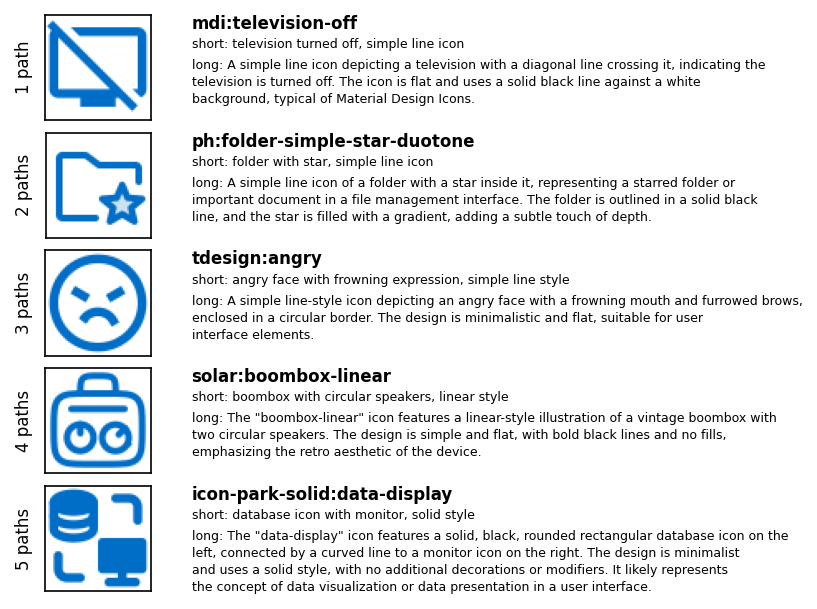

In [21]:
def _render(svg_str: str, size: int = 100) -> np.ndarray:
    colored = re.sub(r'currentColor', '#006EC7', svg_str, flags=re.IGNORECASE)
    png = cairosvg.svg2png(
        bytestring=colored.encode(),
        output_width=size,
        output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

def _icon_border(ax, lw=4):
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.add_patch(FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.05",
        linewidth=lw,
        edgecolor=blue,
        facecolor="none",
        transform=ax.transAxes,
        clip_on=False,
        zorder=10,
    ))


n_paths_rows = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(
    len(n_paths_rows), 2,
    figsize=(7.0, 4.0),
    facecolor="white",
    gridspec_kw={"width_ratios": [1, 4]},
)
fig.subplots_adjust(left=0.12, right=0.85, top=0.98, bottom=0.02, hspace=0.12, wspace=0.05)

for row_i, n_paths in enumerate(n_paths_rows):
    pool = [r for r in eligible if int(r["path_count"]) == n_paths]

    # — icon column —
    ax_img = axes[row_i, 0]
    ax_img.set_facecolor("white")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    ax_img.set_aspect("equal", anchor="N")
    #_icon_border(ax_img)
    ax_img.set_ylabel(
        f"{n_paths} path{'s' if n_paths > 1 else ''}",
        color="black", fontsize=8, labelpad=6,
    )

    # — text column —
    ax_txt = axes[row_i, 1]
    ax_txt.set_facecolor("white")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)
    ax_txt.set_xticks([])
    ax_txt.set_yticks([])
    for sp in ax_txt.spines.values():
        sp.set_visible(False)

    if not pool:
        ax_img.text(0.5, 0.5, "no data", ha="center", va="center",
                    color=blue, fontsize=8, transform=ax_img.transAxes)
        ax_txt.text(0.01, 0.5, "no captioned icons with this path count",
                    ha="left", va="center", color="black", fontsize=9,
                    transform=ax_txt.transAxes)
        continue

    r = random.choice(pool)
    ax_img.imshow(_render(r["svg"], size=64))

    short = r.get("caption_short", "")
    long_ = "\n".join(textwrap.wrap(r.get("caption_long", ""), width=90))

    ax_txt.text(0, 1, r["icon_id"],
                ha="left", va="top", color="black",
                fontsize=8, fontweight="bold",
                transform=ax_txt.transAxes)
    ax_txt.text(0, 0.78, "short: " + short,
                ha="left", va="top", color="black",
                fontsize=6,
                transform=ax_txt.transAxes)
    ax_txt.text(0, 0.58, "long: " + long_,
                ha="left", va="top", color="black",

                fontsize=6, linespacing=1.4,
                transform=ax_txt.transAxes)
plt.savefig("output/icon_caption_examples.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
import statistics

from brand import purple, teal, green, dark_bg

# ── Load merged dataset ───────────────────────────────────────────────────────
MERGED = Path("../data/icons_captioned_merged.jsonl")
merged = []
with open(MERGED) as f:
    for line in f:
        if line.strip():
            merged.append(json.loads(line))

# Fallback: captioner failed to parse SHORT/LONG, wrote normalised icon_name instead.
def _is_fallback(r):
    norm = r["icon_name"].replace("-", " ").replace("_", " ").strip().lower()
    return r["caption_short"].strip().lower() == norm

for r in merged:
    r["_fallback"] = _is_fallback(r)

captioned = [r for r in merged if not r["_fallback"]]
fallback  = [r for r in merged if r["_fallback"]]
n_total, n_cap, n_fall = len(merged), len(captioned), len(fallback)

print(f"Total (merged)     : {n_total:,}")
print(f"  VLM-captioned    : {n_cap:,}  ({100*n_cap/n_total:.1f}%)")
print(f"  Fallback (name)  : {n_fall:,}  ({100*n_fall/n_total:.3f}%)")
print()

# ── Caption length stats ──────────────────────────────────────────────────────
def _stats(vals):
    s = sorted(vals)
    n = len(s)
    return {
        "count":  n,
        "min":    s[0],
        "max":    s[-1],
        "mean":   statistics.mean(s),
        "median": statistics.median(s),
        "p95":    s[int(0.95 * n)],
        "p98":    s[int(0.98 * n)],
        "p99":    s[int(0.99 * n)],
    }

sc = [len(r["caption_short"]) for r in captioned]
lc = [len(r["caption_long"])  for r in captioned]
sf = [len(r["caption_short"]) for r in fallback]
lf = [len(r["caption_long"])  for r in fallback]

hdr = f"{'field':20s}  {'group':12s}  {'count':>7s}  {'min':>4s}  {'max':>4s}  {'mean':>6s}  {'median':>6s}  {'p95':>4s}  {'p98':>4s}  {'p99':>4s}"
print(hdr)
print("─" * len(hdr))
for label, group, vals in [
    ("caption_short", "VLM",      sc),
    ("caption_short", "fallback", sf),
    ("caption_long",  "VLM",      lc),
    ("caption_long",  "fallback", lf),
]:
    st = _stats(vals)
    print(f"{label:20s}  {group:12s}  {st['count']:>7,}  {st['min']:>4d}  {st['max']:>4d}  "
          f"{st['mean']:>6.1f}  {st['median']:>6.1f}  {st['p95']:>4d}  {st['p98']:>4d}  {st['p99']:>4d}")

Total (merged)     : 275,912
  VLM-captioned    : 275,839  (100.0%)
  Fallback (name)  : 73  (0.026%)

field                 group           count   min   max    mean  median   p95   p98   p99
─────────────────────────────────────────────────────────────────────────────────────────
caption_short         VLM           275,839     6    98    42.2    42.0    56    61    64
caption_short         fallback           73     4    43    23.6    27.0    36    38    43
caption_long          VLM           275,839    26   500   252.1   248.0   358   388   408
caption_long          fallback           73     4   168    30.1    27.0   142   149   168


In [23]:
# ── Full 4-case breakdown of parse_captions() fallback behaviour ──────────────
#
# parse_captions() has two independent fallback gates:
#
#   gate A:  if not short:  short  = icon_name   (normalised)
#   gate B:  if not long_:  long_  = short        ← copies current short, not icon_name
#
# Resulting cases for ALL records (not just the 55 _is_fallback hits):
#
#   case 1  SHORT✓  LONG✓  → both real VLM captions          (ideal)
#   case 2  SHORT✓  LONG✗  → long_ = copy of VLM short       (silent quality loss)
#   case 3  SHORT✗  LONG✓  → short = icon_name, long real    (partial fallback)
#   case 4  SHORT✗  LONG✗  → short = long_ = icon_name       (full fallback)

def _norm(r):
    return r["icon_name"].replace("-", " ").replace("_", " ").strip().lower()

case1, case2, case3, case4 = [], [], [], []
for r in merged:
    short_is_name  = r["caption_short"].strip().lower() == _norm(r)
    long_eq_short  = r["caption_long"].strip().lower()  == r["caption_short"].strip().lower()
    if   not short_is_name and not long_eq_short: case1.append(r)
    elif not short_is_name and     long_eq_short: case2.append(r)
    elif     short_is_name and not long_eq_short: case3.append(r)
    else:                                         case4.append(r)

print(f"Case 1  SHORT✓ LONG✓  both real captions        : {len(case1):>7,}  ({100*len(case1)/n_total:.2f}%)")
print(f"Case 2  SHORT✓ LONG✗  long = copy of short      : {len(case2):>7,}  ({100*len(case2)/n_total:.2f}%)")
print(f"Case 3  SHORT✗ LONG✓  short = icon_name, long✓  : {len(case3):>7,}  ({100*len(case3)/n_total:.2f}%)")
print(f"Case 4  SHORT✗ LONG✗  both = icon_name          : {len(case4):>7,}  ({100*len(case4)/n_total:.2f}%)")
print(f"{'Total':49s}: {n_total:>7,}")
print()

rng = random.Random(7)

# Case 2: long is silently a copy of short — confirm with samples
if case2:
    print("── Case 2 samples (LONG missing → long copied from VLM short) ──")
    for r in rng.sample(case2, min(4, len(case2))):
        print(f"  {r['icon_id']}")
        print(f"    short : {r['caption_short']}")
        print(f"    long  : {r['caption_long']}")
        print()

# Case 3: partial fallback — real long, bad short
if case3:
    print("── Case 3 samples (SHORT missing → short = icon_name, long is real) ──")
    for r in rng.sample(case3, min(4, len(case3))):
        print(f"  {r['icon_id']}")
        print(f"    short : {r['caption_short']}")
        print(f"    long  : {r['caption_long'][:120]}{'…' if len(r['caption_long']) > 120 else ''}")
        print()

Case 1  SHORT✓ LONG✓  both real captions        : 275,839  (99.97%)
Case 2  SHORT✓ LONG✗  long = copy of short      :       0  (0.00%)
Case 3  SHORT✗ LONG✓  short = icon_name, long✓  :       4  (0.00%)
Case 4  SHORT✗ LONG✗  both = icon_name          :      69  (0.03%)
Total                                            : 275,912

── Case 3 samples (SHORT missing → short = icon_name, long is real) ──
  dinkie-icons:smiling-face-with-open-mouth-and-cold-sweat
    short : smiling face with open mouth and cold sweat
    long  : Solid black pixelated icon showing a smiling face with wide open mouth and sweat drop, typical of emoji-style emoticons …

  material-symbols-light:settings-input-component-outline-sharp
    short : Settings input component outline sharp
    long  : Three vertical lines with square bases, each with a downward-pointing triangle, minimalist outline style, likely for dev…

  streamline-ultimate:filter-sort-lines-descending-bold
    short : filter sort lines descending bol

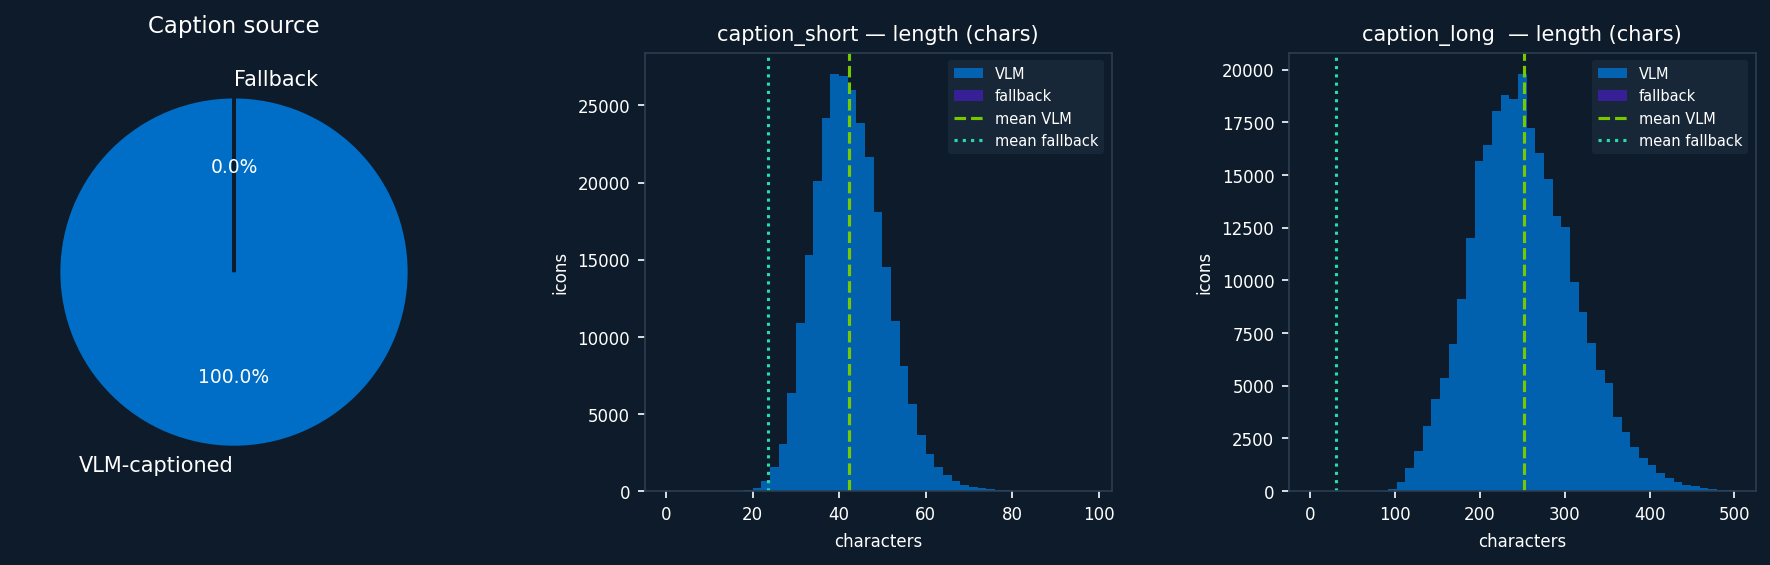

In [24]:
# ── Caption source + length distributions ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor=dark_bg)
fig.subplots_adjust(wspace=0.38, left=0.07, right=0.97, top=0.88, bottom=0.15)

# Pie: VLM-captioned vs fallback
ax = axes[0]
ax.set_facecolor(dark_bg)
_, _, autotexts = ax.pie(
    [n_cap, n_fall],
    labels=["VLM-captioned", "Fallback"],
    colors=[blue, purple],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"color": "white", "fontsize": 10},
    wedgeprops={"linewidth": 1.5, "edgecolor": dark_bg},
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(9)
ax.set_title("Caption source", color="white", fontsize=11, pad=10)

def _hist(ax, vals_a, label_a, vals_b, label_b, title):
    ax.set_facecolor(dark_bg)
    bins = np.linspace(0, max(max(vals_a), max(vals_b)), 50)
    ax.hist(vals_a, bins=bins, color=blue,   alpha=0.85, label=label_a)
    ax.hist(vals_b, bins=bins, color=purple, alpha=0.70, label=label_b)
    ax.axvline(statistics.mean(vals_a), color=green, lw=1.5, ls="--", label=f"mean {label_a}")
    ax.axvline(statistics.mean(vals_b), color=teal,  lw=1.5, ls=":",  label=f"mean {label_b}")
    ax.set_title(title, color="white", fontsize=10)
    ax.set_xlabel("characters", color="white", fontsize=8)
    ax.set_ylabel("icons", color="white", fontsize=8)
    ax.tick_params(colors="white", labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a3d50")
    ax.legend(fontsize=7, labelcolor="white", facecolor="#1a2b3c", edgecolor="none", loc="upper right")

_hist(axes[1], sc, "VLM", sf, "fallback", "caption_short — length (chars)")
_hist(axes[2], lc, "VLM", lf, "fallback", "caption_long  — length (chars)")

plt.savefig("output/caption_length_dist.png", dpi=200, bbox_inches="tight", facecolor=dark_bg)
plt.show()

In [25]:
# print the longest captions
print("\nThe longest caption_short:")
for r in sorted(captioned, key=lambda r: len(r["caption_short"]), reverse=True)[:30]:
    print(f"  {r['icon_id']}: {len(r['caption_short'])} chars — {r['caption_short']}...")


The longest caption_short:
  icon-park-twotone:ethernet-off: 98 chars — black square with rounded corners, solid fill, no additional elements, simple, minimalistic design...
  material-symbols:splitscreen-portrait-outline: 97 chars — splitscreen-portrait-outline, black and white, rectangular, two sections, flat design, UI element...
  simple-icons:apmterminals: 97 chars — A filled, diagonal arrow with a smaller arrow inside, representing a terminal or connection icon....
  material-symbols:battery-android-5-sharp: 96 chars — Battery icon with a filled black background and a white rectangle inside, representing low power...
  material-symbols:desktop-portrait-outline-rounded: 96 chars — outlined rectangular device with rounded corners, representing a desktop in portrait orientation...
  healthicons:symptom-24px: 96 chars — <a stick figure with circular head, arms, and legs, enclosed in a circular outline, health icon>...
  healthicons:symptom-outline-24px: 96 chars — <a stick figure wi

In [26]:
# print the longest captions
print("\nThe longest caption_long:")
for r in sorted(captioned, key=lambda r: len(r["caption_long"]), reverse=True)[:100]:
    print(f"  {r['icon_id']}: {len(r['caption_long'])} chars — {r['caption_long']}...")


The longest caption_long:
  material-symbols:nest-wake-on-press-outline: 500 chars — The icon features a hand in an outline style, pressing a button. It's a wake-on-touch symbol, commonly used in user interface design to indicate that a device or application will wake up when the button is pressed. The hand is positioned as if it's about to press the button, with the thumb and index finger forming the pressing motion. The button itself is a simple vertical line, emphasizing the action of pressing. The overall design is clean and minimalistic, typical of the Material Symbols set....
  material-symbols-light:youtube-searched-for: 500 chars — The SVG icon features a magnifying glass with a curved arrow inside it, symbolizing a search action. The design is minimalist, using a line-style approach with a black outline against a white background. The curved arrow within the magnifying glass suggests a search query or a search result being refined or redirected. This icon is likely used in a 

In [27]:
# ── Sample fallback records ───────────────────────────────────────────────────
rng = random.Random(42)
samples = rng.sample(fallback, min(15, len(fallback)))
print(f"{'icon_id':52s}  caption_short (== icon_name)")
print("─" * 95)
for r in samples:
    print(f"  {r['icon_id']:50s}  {r['caption_short']}")

icon_id                                               caption_short (== icon_name)
───────────────────────────────────────────────────────────────────────────────────────────────
  material-symbols:split-scene-down-outline-rounded   split scene down outline rounded
  material-symbols:contact-phone-outline-rounded      contact phone outline rounded
  material-symbols-light:trackpad-input-outline-rounded  trackpad input outline rounded
  material-symbols-light:readiness-score-outline-rounded  readiness score outline rounded
  material-symbols-light:inbox-text-person-outline-rounded  inbox text person outline rounded
  material-symbols:tools-installation-kit-outline-sharp  tools installation kit outline sharp
  material-symbols:sensor-door-outline-rounded        sensor door outline rounded
  material-symbols:screenshot-keyboard-outline-sharp  screenshot keyboard outline sharp
  stash:search-results-duotone                        search results duotone
  material-symbols:document-scanner-o

### Re-captioning fallback icons

The fallback rate reflects icons where `Qwen2.5-VL` did not emit the expected `SHORT: / LONG:` format; `scripts/02_caption.py` then wrote the normalised `icon_name` into both caption fields (see `parse_captions()` in the script).

**How to re-caption only fallback icons** (3-step pipeline):

```bash
# 1. Extract fallback icons from the merged file into a separate input file
python3 - <<'EOF'
import json
merged = [json.loads(l) for l in open("data/icons_captioned_merged.jsonl")]
def is_fb(r):
    norm = r["icon_name"].replace("-"," ").replace("_"," ").strip().lower()
    return r["caption_short"].strip().lower() == norm
ids = {r["icon_id"] for r in merged if is_fb(r)}
n = 0
with open("data/icons_fallback_only.jsonl","w") as out:
    for line in open("data/icons_filtered.jsonl"):
        if json.loads(line)["icon_id"] in ids:
            out.write(line); n += 1
print(f"Wrote {n:,} icons → data/icons_fallback_only.jsonl")
EOF

# 2. Re-caption (fully resumable — safe to interrupt and restart)
uv run scripts/02_caption.py \
    --input  data/icons_fallback_only.jsonl \
    --output data/icons_recaptioned.jsonl

# 3. Merge back: later entry wins, so re-captioned records override originals
cat data/icons_captioned_merged.jsonl data/icons_recaptioned.jsonl \
  | python3 -c "
import json, sys
seen = {}
for line in sys.stdin:
    r = json.loads(line); seen[r['icon_id']] = line
sys.stdout.writelines(seen.values())
" > data/icons_captioned_v2.jsonl
```

In [31]:
# ── Bad captions in the final training sample ─────────────────────────────────
_SHORT_MAX = 100
_LONG_MAX  = 500

def _bad_reason(r):
    s, lo = r["caption_short"].strip(), r["caption_long"].strip()
    if s.lower() == _norm(r):               return "short=icon_name"
    if s.lower() == lo.lower():             return "long=copy_of_short"
    if len(s)  > _SHORT_MAX:               return f"short_too_long ({len(s)})"
    if len(lo) > _LONG_MAX:                return f"long_too_long ({len(lo)})"
    return None

TRAINING = Path("../data/icons_training.jsonl")
training_ids: set[str] = set()
with open(TRAINING) as f:
    for line in f:
        if line.strip():
            training_ids.add(json.loads(line)["icon_id"])

merged_by_id = {r["icon_id"]: r for r in merged}
train_captioned  = [merged_by_id[i] for i in training_ids if i in merged_by_id]
train_no_caption = [i for i in training_ids if i not in merged_by_id]

print(f"Training icons (icons_training.jsonl) : {len(training_ids):,}")
print(f"  Have a caption in merged            : {len(train_captioned):,}")
print(f"  No caption at all                   : {len(train_no_caption):,}")
print()

t1, t2, t3, t4 = [], [], [], []
for r in train_captioned:
    short_is_name = r["caption_short"].strip().lower() == _norm(r)
    long_eq_short = r["caption_long"].strip().lower()  == r["caption_short"].strip().lower()
    if   not short_is_name and not long_eq_short: t1.append(r)
    elif not short_is_name and     long_eq_short: t2.append(r)
    elif     short_is_name and not long_eq_short: t3.append(r)
    else:                                         t4.append(r)

n_train = len(train_captioned)
print(f"Case 1  SHORT✓ LONG✓  both real captions        : {len(t1):>7,}  ({100*len(t1)/n_train:.2f}%)")
print(f"Case 2  SHORT✓ LONG✗  long = copy of short      : {len(t2):>7,}  ({100*len(t2)/n_train:.2f}%)")
print(f"Case 3  SHORT✗ LONG✓  short = icon_name, long✓  : {len(t3):>7,}  ({100*len(t3)/n_train:.2f}%)")
print(f"Case 4  SHORT✗ LONG✗  both = icon_name          : {len(t4):>7,}  ({100*len(t4)/n_train:.2f}%)")
print()

bad_train = t2 + t3 + t4
if bad_train:
    print(f"Bad captions in training set: {len(bad_train)}")
    for r in sorted(bad_train, key=lambda r: r["icon_id"]):
        print(f"  {r['icon_id']:55s}  {_bad_reason(r) or 'case2/3/4'}")
else:
    print("No bad captions in the training set.")

Training icons (icons_training.jsonl) : 216,209
  Have a caption in merged            : 216,209
  No caption at all                   : 0

Case 1  SHORT✓ LONG✓  both real captions        : 216,139  (99.97%)
Case 2  SHORT✓ LONG✗  long = copy of short      :       0  (0.00%)
Case 3  SHORT✗ LONG✓  short = icon_name, long✓  :       4  (0.00%)
Case 4  SHORT✗ LONG✗  both = icon_name          :      66  (0.03%)

Bad captions in training set: 70
  ant-design:reconciliation-filled                         short=icon_name
  bxs:credit-card-alt                                      short=icon_name
  carbon:navaid-seaplane                                   short=icon_name
  clarity:control-lun-line                                 short=icon_name
  dinkie-icons:smiling-face-with-open-mouth-and-cold-sweat  short=icon_name
  fe:watch-alt                                             short=icon_name
  fluent:border-left-24-filled                             short=icon_name
  fluent:guest-16-regular       